Please follow our [blog](https://medium.com/google-colab) to see more
information about new features, tips and tricks, and featured notebooks such as
[Analyzing a Bank Failure with Colab](https://medium.com/google-colab/noteworthy-notebooks-3-analyzing-a-bank-failure-with-colab-d23b372de313).


In [2]:
import torch
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load dataset
data_folder = './data'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets

print(tr_images.shape, tr_targets.shape)
print(fmnist.classes)

torch.Size([60000, 28, 28]) torch.Size([60000])
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


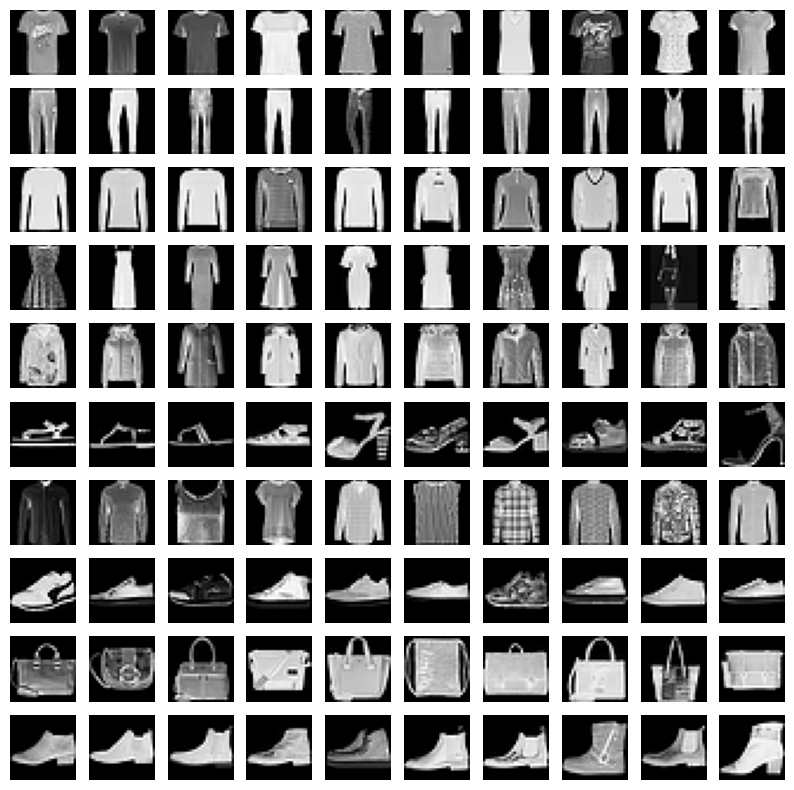

In [3]:
R, C = 10, 10
fig, ax = plt.subplots(R, C, figsize=(10,10))

for label_class, plot_row in enumerate(ax):
    label_x_rows = np.where(tr_targets == label_class)[0]
    for plot_cell in plot_row:
        plot_cell.grid(False)
        plot_cell.axis('off')
        ix = np.random.choice(label_x_rows)
        x = tr_images[ix]
        plot_cell.imshow(x, cmap='gray')

plt.show()

In [5]:
from torch.utils.data import Dataset, DataLoader

class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()/255  # chuẩn hóa (QUAN TRỌNG)
        x = x.view(-1, 28*28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        return self.x[ix].to(device), self.y[ix].to(device)

    def __len__(self):
        return len(self.x)

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    return DataLoader(train, batch_size=32, shuffle=True)

trn_dl = get_data()

In [7]:
import torch.nn as nn
from torch.optim import SGD

def get_model():
    model = nn.Sequential(
        nn.Linear(28*28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer

model, loss_fn, optimizer = get_model()

In [8]:
def train_batch(x, y, model, optimizer, loss_fn):
    model.train()
    pred = model(x)
    loss = loss_fn(pred, y)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    return loss.item()

@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    pred = model(x)
    _, argmax = pred.max(-1)
    return (argmax == y).cpu().numpy().tolist()

In [9]:
losses, accuracies = [], []

for epoch in range(5):
    epoch_losses = []
    epoch_acc = []

    for x, y in trn_dl:
        loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(loss)

    for x, y in trn_dl:
        acc = accuracy(x, y, model)
        epoch_acc.extend(acc)

    losses.append(np.mean(epoch_losses))
    accuracies.append(np.mean(epoch_acc))

    print(f"Epoch {epoch+1}: Loss={losses[-1]:.4f}, Acc={accuracies[-1]:.4f}")

Epoch 1: Loss=0.8475, Acc=0.8070
Epoch 2: Loss=0.5379, Acc=0.8311
Epoch 3: Loss=0.4832, Acc=0.8448
Epoch 4: Loss=0.4551, Acc=0.8479
Epoch 5: Loss=0.4359, Acc=0.8458


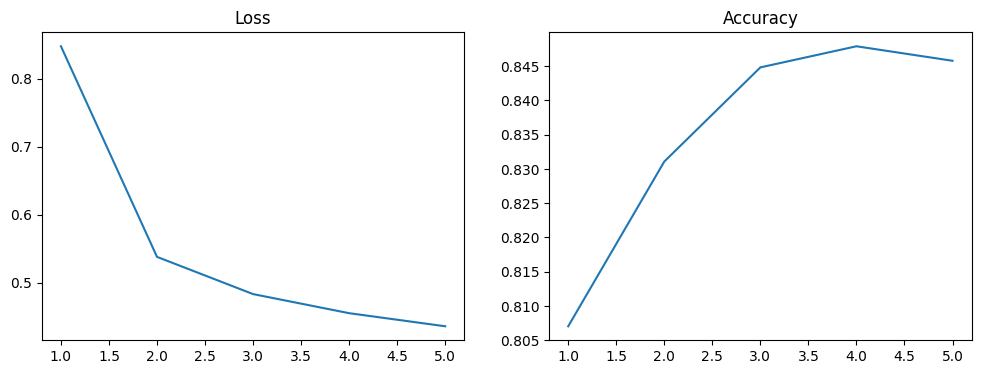

In [10]:
epochs = np.arange(1,6)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs, losses)
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(epochs, accuracies)
plt.title("Accuracy")

plt.show()